In [ ]:
from __future__ import annotations

import time
import logging
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import KFold
from joblib import Parallel, delayed

try:
    import scipy.special  
    HAS_SCIPY = True
except ImportError:
    HAS_SCIPY = False

import matplotlib.pyplot as plt

# =============================================================================
# Global configuration
# =============================================================================
T_DEFAULT = 8
GAMMA_DEFAULT = 0.99
N_DEFAULT = 5000

# DGP defaults
P_MIN_DEFAULT = 1.0
P_MAX_DEFAULT = 10.0
SIGMA_PRICE_DEFAULT = 1.0

# Finite-difference step 
FD_H_DEFAULT = 1e-2

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)


# =============================================================================
# Utilities
# =============================================================================
def set_all_seeds(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass


def choose_device(use_cuda: bool) -> torch.device:
    if use_cuda and torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def _sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))


def _interior_mask(a: np.ndarray, p_min: float, p_max: float, tol: float = 1e-12) -> np.ndarray:
    a = np.asarray(a, dtype=float).reshape(-1)
    return ((a > p_min + tol) & (a < p_max - tol)).astype(float)


def _interior_mask_fd(a: np.ndarray, p_min: float, p_max: float, h: float, tol: float = 1e-12) -> np.ndarray:
    a = np.asarray(a, dtype=float).reshape(-1)
    lo = p_min + max(h, tol)
    hi = p_max - max(h, tol)
    return ((a > lo) & (a < hi)).astype(float)


def _load_matching_state_dict(model: nn.Module, state_dict: Dict[str, torch.Tensor]) -> None:
    """Load only the parameters whose names/shapes match."""
    current = model.state_dict()
    matched = {k: v for k, v in state_dict.items() if (k in current and current[k].shape == v.shape)}
    current.update(matched)
    model.load_state_dict(current)


# =============================================================================
# Trajectory standardization 
# =============================================================================
class TrajectoryStandardizer:
    """
    Global standardizer for state vectors X_t (column-wise) and actions A_t (scalar),
    fit over all (i,t) in the training fold.
    """
    def __init__(self, eps: float = 1e-8):
        self.eps = eps
        self.X_mean: Optional[np.ndarray] = None
        self.X_std: Optional[np.ndarray] = None
        self.A_mean: Optional[float] = None
        self.A_std: Optional[float] = None

    def fit(self, X_seq: np.ndarray, A_seq: np.ndarray) -> "TrajectoryStandardizer":
        X = np.asarray(X_seq, dtype=float).reshape(-1, X_seq.shape[-1])
        A = np.asarray(A_seq, dtype=float).reshape(-1, 1)
        self.X_mean = X.mean(axis=0, keepdims=True)
        self.X_std = np.maximum(X.std(axis=0, keepdims=True), self.eps)
        self.A_mean = float(A.mean())
        self.A_std = float(max(A.std(), self.eps))
        return self

    def transform_X(self, X_seq: np.ndarray) -> np.ndarray:
        assert self.X_mean is not None and self.X_std is not None
        X = np.asarray(X_seq, dtype=float)
        return ((X - self.X_mean) / self.X_std).astype(np.float32)

    def transform_A(self, A_seq: np.ndarray) -> np.ndarray:
        assert self.A_mean is not None and self.A_std is not None
        A = np.asarray(A_seq, dtype=float)
        return ((A - self.A_mean) / self.A_std).astype(np.float32)


# =============================================================================
# 1) Reference-price simulator 
# =============================================================================
def generate_data_mpe(
    N: int,
    T: int = T_DEFAULT,
    gamma: float = GAMMA_DEFAULT,
    alpha: float = 0.8,
    beta0: float = 3.0,
    beta1: float = -0.7,
    beta2: float = 1.0,
    w0: float = 5.0,
    w1: float = 0.2,
    sigma_price: float = SIGMA_PRICE_DEFAULT,
    p_min: float = P_MIN_DEFAULT,
    p_max: float = P_MAX_DEFAULT,
    r0_mean: float = 5.0,
    r0_std: float = 1.0,
    eps_shift: float = 0.0,
    seed: Optional[int] = None,
) -> Dict:

    rng = np.random.default_rng(seed)

    X: List[Optional[np.ndarray]] = [None] * (T + 1)
    A: List[Optional[np.ndarray]] = [None] * (T + 1)
    mA: List[Optional[np.ndarray]] = [None] * (T + 1)
    varA: List[Optional[np.ndarray]] = [None] * (T + 1)
    R: List[Optional[np.ndarray]] = [None] * (T + 1)

    r = r0_mean + r0_std * rng.standard_normal(size=(N, 1))
    r = np.clip(r, p_min, p_max)

    seg = (2 * rng.integers(0, 2, size=(N, 1)) - 1).astype(float)
    z1 = rng.standard_normal(size=(N, 1))
    z2 = rng.standard_normal(size=(N, 1))

    A_prev = np.clip(w0 + w1 * r + 0.4 * seg + 0.3 * np.tanh(z2), p_min, p_max)

    Y = np.zeros((N, 1))
    disc = 1.0

    ref_noise = 0.05
    z_noise = 0.35

    for t in range(1, T + 1):
        t_frac = (t / T) * np.ones((N, 1))
        X_t = np.hstack([r, seg, z1, z2, t_frac])
        X[t] = X_t

        mu_base = (
            w0
            + w1 * r
            + 0.4 * seg
            + 0.30 * np.tanh(z2)
            + 0.25 * np.tanh((A_prev - r) / 2.0)
            + 0.15 * np.sin(2.0 * np.pi * (t / T)) * z1
        )
        mu = mu_base + eps_shift
        var_t = (sigma_price ** 2) * np.ones_like(mu_base)

        A_raw = mu + sigma_price * rng.standard_normal(size=(N, 1))
        A_t = np.clip(A_raw, p_min, p_max)

        A[t] = A_t
        mA[t] = mu_base
        varA[t] = var_t

        price_sens = beta1 * (1.0 + 0.35 * np.tanh(z1))
        demand_lin = (
            beta0
            + price_sens * A_t
            + beta2 * (r - A_t)
            - 0.12 * (A_t - r) ** 2
            + 0.35 * np.sin(A_t)
            + 0.25 * seg
            + 0.15 * z2
        )
        p_demand = _sigmoid(demand_lin)
        purchase = (rng.random(size=(N, 1)) < p_demand).astype(float)

        R_t = A_t  * purchase
        R[t] = R_t

        Y += disc * R_t
        disc *= gamma

        r_old = r
        r = alpha * r + (1.0 - alpha) * A_t + 0.15 * np.tanh(z1) + ref_noise * rng.standard_normal(size=(N, 1))
        r = np.clip(r, p_min, p_max)

        z1 = 0.65 * z1 + 0.20 * np.tanh((A_t - r_old) / 2.0) + z_noise * rng.standard_normal(size=(N, 1))
        z2 = 0.50 * z2 + 0.15 * np.sin(A_t - r_old) + z_noise * rng.standard_normal(size=(N, 1))
        z1 = np.clip(z1, -4.0, 4.0)
        z2 = np.clip(z2, -4.0, 4.0)

        A_prev = A_t

    S: List[Optional[np.ndarray]] = [None] * (T + 1)
    for t in range(1, T + 1):
        parts = []
        for j in range(1, t):
            parts.extend([X[j], A[j]])
        parts.append(X[t])
        S[t] = np.hstack(parts)

    p = X[1].shape[1]
    return {
        "X": X,
        "A": A,
        "mA": mA,
        "varA": varA,
        "S": S,
        "R": R,
        "Y": Y.flatten(),
        "gamma": gamma,
        "T": T,
        "N": N,
        "p": p,
        "p_min": p_min,
        "p_max": p_max,
        "sigma_price": sigma_price,
        "w0": w0,
        "w1": w1,
        "alpha": alpha,
        "beta0": beta0,
        "beta1": beta1,
        "beta2": beta2,
    }


def subset_data(data: Dict, idx: np.ndarray) -> Dict:
    T = data["T"]
    out = {
        "gamma": data["gamma"],
        "T": T,
        "N": len(idx),
        "p": data["p"],
        "p_min": data["p_min"],
        "p_max": data["p_max"],
        "sigma_price": data["sigma_price"],
        "w0": data["w0"],
        "w1": data["w1"],
        "alpha": data["alpha"],
        "beta0": data["beta0"],
        "beta1": data["beta1"],
        "beta2": data["beta2"],
    }
    for key in ["X", "A", "mA", "varA", "S", "R"]:
        out[key] = [None] * (T + 1)
        for t in range(1, T + 1):
            out[key][t] = data[key][t][idx].copy()
    out["Y"] = data["Y"][idx].copy()
    return out


def extract_XA_sequences(data: Dict) -> Tuple[np.ndarray, np.ndarray]:
    T = data["T"]
    X_seq = np.stack([data["X"][t] for t in range(1, T + 1)], axis=1).astype(np.float32)
    A_seq = np.stack([data["A"][t] for t in range(1, T + 1)], axis=1).astype(np.float32)
    if A_seq.ndim == 2:
        A_seq = A_seq[..., None]
    return X_seq, A_seq


# =============================================================================
# 2) Cumulative returns
# =============================================================================
def compute_returns_to_go(data: Dict) -> List[np.ndarray]:
    T = data["T"]
    gamma = data["gamma"]
    R = data["R"]
    N = data["N"]

    G: List[Optional[np.ndarray]] = [None] * (T + 2)
    G[T + 1] = np.zeros(N, dtype=float)
    for t in range(T, 0, -1):
        G[t] = R[t].flatten() + gamma * G[t + 1]
    return G  # type: ignore


def returns_to_go_matrix(data: Dict) -> np.ndarray:
    T = data["T"]
    G = compute_returns_to_go(data)
    return np.stack([G[t] for t in range(1, T + 1)], axis=1).astype(np.float32)


# =============================================================================
# 3) Shared recurrent nuisances 
# =============================================================================
class CausalTrajectoryGRU(nn.Module):
    """
    Causal recurrent encoder over an interleaved token sequence
        [X_1, A_1, X_2, A_2, ..., X_T, A_T].

    The hidden state at token X_t depends on
        {X_1,A_1,...,X_t,A_{t-1}}
    but not on A_t or later tokens, so it is a valid learned representation of the
    full observed prefix S_t.

    This is strictly cheaper than a transformer for the same task, while preserving
    the same full-history conditioning logic.
    """
    def __init__(
        self,
        x_dim: int,
        d_model: int = 128,
        n_layers: int = 2,
        dropout: float = 0.1,
        activation: str = "silu",
    ):
        super().__init__()
        self.x_dim = int(x_dim)
        self.d_model = int(d_model)

        self.x_proj = nn.Linear(self.x_dim, self.d_model)
        self.a_proj = nn.Linear(1, self.d_model)
        self.type_emb = nn.Embedding(2, self.d_model)

        act = activation.lower()
        if act == "relu":
            self.pre = nn.ReLU()
        elif act == "gelu":
            self.pre = nn.GELU()
        elif act in {"silu", "swish"}:
            self.pre = nn.SiLU()
        else:
            raise ValueError("activation must be one of {'relu','gelu','silu'}")

        self.gru = nn.GRU(
            input_size=self.d_model,
            hidden_size=self.d_model,
            num_layers=int(n_layers),
            batch_first=True,
            dropout=float(dropout) if int(n_layers) > 1 else 0.0,
        )
        self.out_dropout = nn.Dropout(float(dropout))
        self.norm = nn.LayerNorm(self.d_model)

    def forward(self, X_seq: torch.Tensor, A_seq: torch.Tensor) -> torch.Tensor:
        B, T, dx = X_seq.shape
        if dx != self.x_dim:
            raise ValueError(f"X_seq last dim = {dx}, expected {self.x_dim}")

        x_tok = self.pre(self.x_proj(X_seq))
        a_tok = self.pre(self.a_proj(A_seq))

        L = 2 * T
        tokens = torch.empty(B, L, self.d_model, device=X_seq.device, dtype=X_seq.dtype)
        tokens[:, 0::2, :] = x_tok
        tokens[:, 1::2, :] = a_tok

        type_ids = torch.zeros(L, device=X_seq.device, dtype=torch.long)
        type_ids[1::2] = 1
        tokens = tokens + self.type_emb(type_ids)[None, :, :]

        out, _ = self.gru(tokens)
        out = self.out_dropout(self.norm(out))
        return out[:, 0::2, :]


class ActionMLPHead(nn.Module):
    def __init__(
        self,
        d_model: int,
        hidden_dim: int = 128,
        n_layers: int = 2,
        dropout: float = 0.05,
        activation: str = "gelu",
    ):
        super().__init__()
        act = activation.lower()
        if act == "relu":
            Act = nn.ReLU
        elif act == "gelu":
            Act = nn.GELU
        elif act in {"silu", "swish"}:
            Act = nn.SiLU
        else:
            raise ValueError("activation must be one of {'relu','gelu','silu'}")

        layers: List[nn.Module] = []
        d = d_model + 1
        for _ in range(int(n_layers)):
            layers.append(nn.Linear(d, hidden_dim))
            layers.append(Act())
            if dropout and dropout > 0.0:
                layers.append(nn.Dropout(float(dropout)))
            d = hidden_dim
        layers.append(nn.Linear(d, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, h: torch.Tensor, a_scaled: torch.Tensor) -> torch.Tensor:
        B, T, d_model = h.shape
        x = torch.cat([h, a_scaled], dim=-1).reshape(B * T, d_model + 1)
        y = self.net(x).reshape(B, T)
        return y


class RecurrentActionMLP(nn.Module):
    def __init__(
        self,
        x_dim: int,
        d_model: int = 128,
        n_layers: int = 2,
        dropout: float = 0.1,
        activation: str = "silu",
        head_hidden: int = 128,
        head_layers: int = 2,
        head_dropout: float = 0.05,
        head_activation: str = "gelu",
    ):
        super().__init__()
        self.encoder = CausalTrajectoryGRU(
            x_dim=x_dim,
            d_model=d_model,
            n_layers=n_layers,
            dropout=dropout,
            activation=activation,
        )
        self.head = ActionMLPHead(
            d_model=d_model,
            hidden_dim=head_hidden,
            n_layers=head_layers,
            dropout=head_dropout,
            activation=head_activation,
        )

    def encode(self, X_seq: torch.Tensor, A_seq_scaled: torch.Tensor) -> torch.Tensor:
        return self.encoder(X_seq, A_seq_scaled)

    def forward_from_h(self, h: torch.Tensor, a_scaled: torch.Tensor) -> torch.Tensor:
        return self.head(h, a_scaled)

    def forward(self, X_seq: torch.Tensor, A_seq_scaled: torch.Tensor) -> torch.Tensor:
        h = self.encoder(X_seq, A_seq_scaled)
        return self.head(h, A_seq_scaled)


# =============================================================================
# 4) Training helpers
# =============================================================================
def _split_train_val(n: int, val_frac: float, rng: np.random.Generator) -> Tuple[np.ndarray, np.ndarray]:
    n_val = int(round(val_frac * n))
    perm = rng.permutation(n)
    if n_val <= 0:
        return perm, np.array([], dtype=int)
    return perm[n_val:], perm[:n_val]


def _make_loader(
    X: np.ndarray,
    A: np.ndarray,
    Y: Optional[np.ndarray],
    batch_size: int,
    shuffle: bool,
) -> DataLoader:
    if Y is None:
        ds = TensorDataset(
            torch.tensor(X, dtype=torch.float32),
            torch.tensor(A, dtype=torch.float32),
        )
    else:
        ds = TensorDataset(
            torch.tensor(X, dtype=torch.float32),
            torch.tensor(A, dtype=torch.float32),
            torch.tensor(Y, dtype=torch.float32),
        )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, pin_memory=torch.cuda.is_available())


@dataclass
class QModel:
    net: RecurrentActionMLP
    scaler: TrajectoryStandardizer


@dataclass
class KappaModel:
    net: RecurrentActionMLP
    scaler: TrajectoryStandardizer


# =============================================================================
# 5) Q learning 
# =============================================================================
def train_q_recurrent_return_to_go(
    X_seq_scaled: np.ndarray,
    A_seq_scaled: np.ndarray,
    G_seq: np.ndarray,
    scaler: TrajectoryStandardizer,
    device: torch.device,
    d_model: int = 128,
    n_layers: int = 2,
    dropout: float = 0.1,
    activation: str = "silu",
    head_hidden: int = 128,
    head_layers: int = 2,
    head_dropout: float = 0.05,
    head_activation: str = "gelu",
    n_epochs: int = 100,
    lr: float = 5e-4,
    batch_size: int = 256,
    weight_decay: float = 1e-4,
    val_frac: float = 0.1,
    patience: int = 20,
    grad_clip: float = 5.0,
    seed: int = 123,
    use_amp: bool = True,
) -> QModel:
    rng = np.random.default_rng(seed)
    N, _, x_dim = X_seq_scaled.shape

    tr_idx, val_idx = _split_train_val(N, val_frac=val_frac, rng=rng)
    loader = _make_loader(X_seq_scaled[tr_idx], A_seq_scaled[tr_idx], G_seq[tr_idx], batch_size=batch_size, shuffle=True)

    Xv = torch.tensor(X_seq_scaled[val_idx], dtype=torch.float32, device=device) if len(val_idx) > 0 else None
    Av = torch.tensor(A_seq_scaled[val_idx], dtype=torch.float32, device=device) if len(val_idx) > 0 else None
    Yv = torch.tensor(G_seq[val_idx], dtype=torch.float32, device=device) if len(val_idx) > 0 else None

    net = RecurrentActionMLP(
        x_dim=x_dim,
        d_model=d_model,
        n_layers=n_layers,
        dropout=dropout,
        activation=activation,
        head_hidden=head_hidden,
        head_layers=head_layers,
        head_dropout=head_dropout,
        head_activation=head_activation,
    ).to(device)

    opt = optim.AdamW(net.parameters(), lr=lr, weight_decay=weight_decay)
    amp_enabled = bool(use_amp and device.type == "cuda")
    grad_scaler = torch.amp.GradScaler('cuda', enabled=amp_enabled)

    best_state = None
    best_val = float("inf")
    no_imp = 0

    for _ in range(n_epochs):
        net.train()
        for xb, ab, yb in loader:
            xb = xb.to(device, non_blocking=True)
            ab = ab.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=amp_enabled):
                pred = net(xb, ab)
                loss = ((pred - yb) ** 2).mean()
            grad_scaler.scale(loss).backward()
            if grad_clip is not None:
                grad_scaler.unscale_(opt)
                nn.utils.clip_grad_norm_(net.parameters(), grad_clip)
            grad_scaler.step(opt)
            grad_scaler.update()

        if Xv is not None:
            net.eval()
            with torch.no_grad():
                pv = net(Xv, Av)
                val_loss = ((pv - Yv) ** 2).mean().item()
            if val_loss < best_val - 1e-6:
                best_val = val_loss
                best_state = {k: v.detach().cpu().clone() for k, v in net.state_dict().items()}
                no_imp = 0
            else:
                no_imp += 1
                if no_imp >= patience:
                    break

    if best_state is not None:
        net.load_state_dict(best_state)
    net.eval()
    return QModel(net=net, scaler=scaler)


# =============================================================================
# 6) score learning via variational Riesz 
# =============================================================================
def train_kappa_recurrent_variational(
    X_seq_scaled: np.ndarray,
    A_seq_scaled: np.ndarray,
    gamma: float,
    p_min: float,
    p_max: float,
    scaler: TrajectoryStandardizer,
    device: torch.device,
    d_model: int = 128,
    n_layers: int = 2,
    dropout: float = 0.1,
    activation: str = "silu",
    head_hidden: int = 128,
    head_layers: int = 2,
    head_dropout: float = 0.05,
    head_activation: str = "gelu",
    n_epochs: int = 100,
    lr: float = 5e-4,
    batch_size: int = 256,
    weight_decay: float = 1e-4,
    val_frac: float = 0.1,
    patience: int = 20,
    grad_clip: float = 5.0,
    grad_penalty: float = 0.0,
    fd_h: float = FD_H_DEFAULT,
    seed: int = 123,
    use_amp: bool = True,
    init_state_dict: Optional[Dict[str, torch.Tensor]] = None,
) -> KappaModel:
    """
    Variational/Riesz regression with one shared full-history encoder across all t.

    We minimize the pooled objective
        E_n[ κ(Z)^2 - 2 γ^{t-1} ∂_a κ(Z) * 1{A_t ± h within bounds} ]
    using finite differences only in the current action coordinate. The encoder is reused
    within a batch, so each batch performs one history-encoding pass and three head passes.
    """
    rng = np.random.default_rng(seed)
    N, T, x_dim = X_seq_scaled.shape

    tr_idx, val_idx = _split_train_val(N, val_frac=val_frac, rng=rng)
    loader = _make_loader(X_seq_scaled[tr_idx], A_seq_scaled[tr_idx], None, batch_size=batch_size, shuffle=True)

    Xv = torch.tensor(X_seq_scaled[val_idx], dtype=torch.float32, device=device) if len(val_idx) > 0 else None
    Av = torch.tensor(A_seq_scaled[val_idx], dtype=torch.float32, device=device) if len(val_idx) > 0 else None

    gamma_pow = torch.tensor([gamma ** t for t in range(T)], dtype=torch.float32, device=device)[None, :]
    a_std = float(scaler.A_std)
    a_mean = float(scaler.A_mean)
    delta_scaled = float(fd_h / a_std)

    net = RecurrentActionMLP(
        x_dim=x_dim,
        d_model=d_model,
        n_layers=n_layers,
        dropout=dropout,
        activation=activation,
        head_hidden=head_hidden,
        head_layers=head_layers,
        head_dropout=head_dropout,
        head_activation=head_activation,
    ).to(device)
    if init_state_dict is not None:
        _load_matching_state_dict(net, init_state_dict)

    opt = optim.AdamW(net.parameters(), lr=lr, weight_decay=weight_decay)
    amp_enabled = bool(use_amp and device.type == "cuda")
    grad_scaler = torch.amp.GradScaler('cuda', enabled=amp_enabled)

    best_state = None
    best_val = float("inf")
    no_imp = 0

    for _ in range(n_epochs):
        net.train()
        for xb, ab in loader:
            xb = xb.to(device, non_blocking=True)
            ab = ab.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=amp_enabled):
                h = net.encode(xb, ab)
                pred0 = net.forward_from_h(h, ab)
                pred_plus = net.forward_from_h(h, ab + delta_scaled)
                pred_minus = net.forward_from_h(h, ab - delta_scaled)
                d_pred_dA = (pred_plus - pred_minus) / (2.0 * float(fd_h))

                a_orig = ab * a_std + a_mean
                mask = ((a_orig > (p_min + float(fd_h) + 1e-12)) & (a_orig < (p_max - float(fd_h) - 1e-12))).float().squeeze(-1)

                loss = (pred0 ** 2 - 2.0 * gamma_pow * d_pred_dA * mask).mean()
                if grad_penalty and grad_penalty > 0.0:
                    loss = loss + float(grad_penalty) * ((d_pred_dA * mask) ** 2).mean()

            grad_scaler.scale(loss).backward()
            if grad_clip is not None:
                grad_scaler.unscale_(opt)
                nn.utils.clip_grad_norm_(net.parameters(), grad_clip)
            grad_scaler.step(opt)
            grad_scaler.update()

        if Xv is not None:
            net.eval()
            with torch.no_grad():
                hv = net.encode(Xv, Av)
                pv0 = net.forward_from_h(hv, Av)
                pv_plus = net.forward_from_h(hv, Av + delta_scaled)
                pv_minus = net.forward_from_h(hv, Av - delta_scaled)
                dv = (pv_plus - pv_minus) / (2.0 * float(fd_h))

                a_orig_v = Av * a_std + a_mean
                mask_v = ((a_orig_v > (p_min + float(fd_h) + 1e-12)) & (a_orig_v < (p_max - float(fd_h) - 1e-12))).float().squeeze(-1)
                val_loss = (pv0 ** 2 - 2.0 * gamma_pow * dv * mask_v).mean().item()
                if grad_penalty and grad_penalty > 0.0:
                    val_loss += float(grad_penalty) * ((dv * mask_v) ** 2).mean().item()

            if val_loss < best_val - 1e-6:
                best_val = val_loss
                best_state = {k: v.detach().cpu().clone() for k, v in net.state_dict().items()}
                no_imp = 0
            else:
                no_imp += 1
                if no_imp >= patience:
                    break

    if best_state is not None:
        net.load_state_dict(best_state)
    net.eval()
    return KappaModel(net=net, scaler=scaler)


# =============================================================================
# 7) Batched prediction helpers
# =============================================================================
def _batched_predict_matrix(
    model: RecurrentActionMLP,
    Xs: np.ndarray,
    As: np.ndarray,
    device: torch.device,
    batch_size: int = 1024,
) -> np.ndarray:
    model.to(device).eval()
    N = Xs.shape[0]
    T = Xs.shape[1]
    out = np.zeros((N, T), dtype=np.float32)

    with torch.no_grad():
        for start in range(0, N, batch_size):
            end = min(N, start + batch_size)
            xb = torch.tensor(Xs[start:end], dtype=torch.float32, device=device)
            ab = torch.tensor(As[start:end], dtype=torch.float32, device=device)
            pred = model(xb, ab)
            out[start:end] = pred.detach().cpu().numpy().astype(np.float32)
    return out.astype(float)


def _batched_q_fd_matrix(
    model: RecurrentActionMLP,
    Xs: np.ndarray,
    As: np.ndarray,
    scaler: TrajectoryStandardizer,
    device: torch.device,
    p_min: float,
    p_max: float,
    fd_h: float,
    batch_size: int = 1024,
) -> np.ndarray:
    """
    Finite-difference derivative wrt ORIGINAL action scale.
    Uses one-sided differences near the action bounds.
    """
    model.to(device).eval()
    N = Xs.shape[0]
    T = Xs.shape[1]
    out = np.zeros((N, T), dtype=np.float32)

    a_mean = float(scaler.A_mean)
    a_std = float(scaler.A_std)

    with torch.no_grad():
        for start in range(0, N, batch_size):
            end = min(N, start + batch_size)
            xb = torch.tensor(Xs[start:end], dtype=torch.float32, device=device)
            ab = torch.tensor(As[start:end], dtype=torch.float32, device=device)

            h = model.encode(xb, ab)

            a_orig = ab * a_std + a_mean
            a_plus_orig = torch.clamp(a_orig + float(fd_h), min=p_min, max=p_max)
            a_minus_orig = torch.clamp(a_orig - float(fd_h), min=p_min, max=p_max)
            denom = torch.clamp(a_plus_orig - a_minus_orig, min=1e-8)

            a_plus = (a_plus_orig - a_mean) / a_std
            a_minus = (a_minus_orig - a_mean) / a_std

            q_plus = model.forward_from_h(h, a_plus)
            q_minus = model.forward_from_h(h, a_minus)
            dq = (q_plus - q_minus) / denom.squeeze(-1)
            out[start:end] = dq.detach().cpu().numpy().astype(np.float32)

    return out.astype(float)


def predict_q_hat_matrix(
    q_model: QModel,
    data_te: Dict,
    device: torch.device,
    batch_size: int = 1024,
) -> np.ndarray:
    X_seq, A_seq = extract_XA_sequences(data_te)
    Xs = q_model.scaler.transform_X(X_seq)
    As = q_model.scaler.transform_A(A_seq)
    return _batched_predict_matrix(q_model.net, Xs, As, device=device, batch_size=batch_size)


def predict_kappa_hat_matrix(
    kappa_model: KappaModel,
    data_te: Dict,
    device: torch.device,
    batch_size: int = 1024,
) -> np.ndarray:
    X_seq, A_seq = extract_XA_sequences(data_te)
    Xs = kappa_model.scaler.transform_X(X_seq)
    As = kappa_model.scaler.transform_A(A_seq)
    return _batched_predict_matrix(kappa_model.net, Xs, As, device=device, batch_size=batch_size)


def predict_q_fd_matrix(
    q_model: QModel,
    data_te: Dict,
    device: torch.device,
    fd_h: float = FD_H_DEFAULT,
    batch_size: int = 1024,
) -> np.ndarray:
    X_seq, A_seq = extract_XA_sequences(data_te)
    Xs = q_model.scaler.transform_X(X_seq)
    As = q_model.scaler.transform_A(A_seq)
    return _batched_q_fd_matrix(
        q_model.net,
        Xs,
        As,
        scaler=q_model.scaler,
        device=device,
        p_min=float(data_te["p_min"]),
        p_max=float(data_te["p_max"]),
        fd_h=float(fd_h),
        batch_size=batch_size,
    )


# =============================================================================
# 8) Oracle score for clipped Gaussian (benchmark / score-known direct term)
# =============================================================================
def _logphi(z: np.ndarray) -> np.ndarray:
    return -0.5 * z ** 2 - 0.5 * np.log(2.0 * np.pi)


def _logcdf_standard_normal(z: np.ndarray) -> np.ndarray:
    if HAS_SCIPY:
        return scipy.special.log_ndtr(z)
    from math import erf, sqrt
    z = np.asarray(z, dtype=float)
    cdf = 0.5 * (1.0 + np.vectorize(erf)(z / sqrt(2.0)))
    return np.log(np.maximum(cdf, 1e-300))


def _logsf_standard_normal(z: np.ndarray) -> np.ndarray:
    if HAS_SCIPY:
        return scipy.special.log_ndtr(-z)
    from math import erf, sqrt
    z = np.asarray(z, dtype=float)
    cdf = 0.5 * (1.0 + np.vectorize(erf)(z / sqrt(2.0)))
    return np.log(np.maximum(1.0 - cdf, 1e-300))


def kappa_oracle_clipped_gaussian(data: Dict, var_floor: float = 1e-12) -> List[np.ndarray]:
    T = data["T"]
    gamma = data["gamma"]
    A = data["A"]
    mA = data["mA"]
    sigma = float(data["sigma_price"])
    p_min = float(data["p_min"])
    p_max = float(data["p_max"])

    sig2 = max(sigma ** 2, var_floor)

    def phi(z: np.ndarray) -> np.ndarray:
        return np.exp(_logphi(z))

    def Phi(z: np.ndarray) -> np.ndarray:
        return np.exp(_logcdf_standard_normal(z))

    kappa: List[Optional[np.ndarray]] = [None] * (T + 1)
    for t in range(1, T + 1):
        a = A[t].flatten()
        mu0 = mA[t].flatten()

        is_low = np.isclose(a, p_min)
        is_high = np.isclose(a, p_max)
        is_mid = ~(is_low | is_high)

        H = np.empty_like(a, dtype=float)
        if np.any(is_mid):
            H[is_mid] = (a[is_mid] - mu0[is_mid]) / sig2
        if np.any(is_low):
            zL = (p_min - mu0[is_low]) / sigma
            denom = np.maximum(Phi(zL), 1e-300)
            H[is_low] = -phi(zL) / (sigma * denom)
        if np.any(is_high):
            zU = (p_max - mu0[is_high]) / sigma
            denom = np.maximum(np.exp(_logsf_standard_normal(zU)), 1e-300)
            H[is_high] = phi(zU) / (sigma * denom)
        kappa[t] = (gamma ** (t - 1)) * H
    return kappa  # type: ignore


def kappa_oracle_matrix(data: Dict) -> np.ndarray:
    T = data["T"]
    k_list = kappa_oracle_clipped_gaussian(data)
    return np.stack([k_list[t] for t in range(1, T + 1)], axis=1).astype(np.float32)


# =============================================================================
# 9) Cross-fitted estimation
# =============================================================================
@dataclass
class CrossFitResult:
    theta_direct: float
    theta_asrw: float
    theta_asrw_oraclek: float
    theta_srw: float

    contrib_direct: np.ndarray
    contrib_asrw: np.ndarray
    contrib_asrw_oraclek: np.ndarray
    contrib_srw: np.ndarray

    fold_id: np.ndarray
    fold_means: Dict[str, np.ndarray]
    fold_weights: np.ndarray


def estimate_mpe_crossfit(
    data: Dict,
    n_splits_cf: int = 5,
    use_cuda: bool = False,
    # q shared recurrent nuisance
    q_d_model: int = 128,
    q_n_layers: int = 2,
    q_dropout: float = 0.10,
    q_activation: str = "silu",
    q_head_hidden: int = 128,
    q_head_layers: int = 2,
    q_head_dropout: float = 0.05,
    q_head_activation: str = "gelu",
    q_n_epochs: int = 100,
    q_lr: float = 5e-4,
    q_batch_size: int = 256,
    q_weight_decay: float = 1e-4,
    # κ shared recurrent nuisance
    k_d_model: int = 128,
    k_n_layers: int = 2,
    k_dropout: float = 0.10,
    k_activation: str = "silu",
    k_head_hidden: int = 128,
    k_head_layers: int = 2,
    k_head_dropout: float = 0.05,
    k_head_activation: str = "gelu",
    k_n_epochs: int = 100,
    k_lr: float = 5e-4,
    k_batch_size: int = 256,
    k_weight_decay: float = 1e-4,
    random_state_kappa: int = 123,
    grad_penalty_kappa: float = 0.0,
    warm_start_kappa_from_q: bool = True,
    # direct term
    direct_method: str = "score_oracle",  # or 'fd'
    h_direct: float = FD_H_DEFAULT,
    # misc
    pred_batch_size: int = 1024,
    use_amp: bool = True,
) -> CrossFitResult:
    """
    Main computational change relative to the original 2*T*K design:
      - one shared q model per fold
      - one shared κ model per fold
    instead of one fresh model at every stage t.

    direct_method:
      - 'score_oracle': matches the clipped-Gaussian score-form direct term from your
        current reference-price code.
      - 'fd': uses a finite-difference derivative of q wrt current action. This is available
        if you want the pathwise direct term while still keeping the pooled shared nuisance.
    """
    N = data["N"]
    T = data["T"]
    gamma = float(data["gamma"])
    gamma_pow = np.asarray([gamma ** t for t in range(T)], dtype=float)[None, :]
    device = choose_device(use_cuda)

    idx = np.arange(N)
    kf = KFold(n_splits=n_splits_cf, shuffle=True, random_state=123)

    contrib_direct_all = np.zeros(N)
    contrib_asrw_all = np.zeros(N)
    contrib_asrw_oraclek_all = np.zeros(N)
    contrib_srw_all = np.zeros(N)
    fold_id_of_obs = -np.ones(N, dtype=int)

    fold_means_direct = []
    fold_means_asrw = []
    fold_means_asrw_oraclek = []
    fold_means_srw = []
    fold_weights = []

    for fold_id, (tr_idx, te_idx) in enumerate(kf.split(idx), start=0):
        d_tr = subset_data(data, tr_idx)
        d_te = subset_data(data, te_idx)
        fold_id_of_obs[te_idx] = fold_id
        fold_weights.append(len(te_idx) / N)

        X_tr, A_tr = extract_XA_sequences(d_tr)
        G_tr = returns_to_go_matrix(d_tr)

        # One scaler per fold, shared by q and κ.
        scaler = TrajectoryStandardizer().fit(X_tr, A_tr)
        X_tr_s = scaler.transform_X(X_tr)
        A_tr_s = scaler.transform_A(A_tr)

        q_model = train_q_recurrent_return_to_go(
            X_seq_scaled=X_tr_s,
            A_seq_scaled=A_tr_s,
            G_seq=G_tr,
            scaler=scaler,
            device=device,
            d_model=q_d_model,
            n_layers=q_n_layers,
            dropout=q_dropout,
            activation=q_activation,
            head_hidden=q_head_hidden,
            head_layers=q_head_layers,
            head_dropout=q_head_dropout,
            head_activation=q_head_activation,
            n_epochs=q_n_epochs,
            lr=q_lr,
            batch_size=q_batch_size,
            weight_decay=q_weight_decay,
            seed=123 + 10 * fold_id,
            use_amp=use_amp,
        )

        q_hat_te = predict_q_hat_matrix(q_model, d_te, device=device, batch_size=pred_batch_size)
        G_te = returns_to_go_matrix(d_te).astype(float)
        kappa_star_te = kappa_oracle_matrix(d_te).astype(float)

        if direct_method == "score_oracle":
            c_dir = (kappa_star_te * q_hat_te).sum(axis=1)
        elif direct_method == "fd":
            dq_da_te = predict_q_fd_matrix(q_model, d_te, device=device, fd_h=h_direct, batch_size=pred_batch_size)
            c_dir = (gamma_pow * dq_da_te).sum(axis=1)
        else:
            raise ValueError("direct_method must be 'score_oracle' or 'fd'.")

        init_state = q_model.net.state_dict() if warm_start_kappa_from_q else None
        kappa_model = train_kappa_recurrent_variational(
            X_seq_scaled=X_tr_s,
            A_seq_scaled=A_tr_s,
            gamma=float(d_tr["gamma"]),
            p_min=float(d_tr["p_min"]),
            p_max=float(d_tr["p_max"]),
            scaler=scaler,
            device=device,
            d_model=k_d_model,
            n_layers=k_n_layers,
            dropout=k_dropout,
            activation=k_activation,
            head_hidden=k_head_hidden,
            head_layers=k_head_layers,
            head_dropout=k_head_dropout,
            head_activation=k_head_activation,
            n_epochs=k_n_epochs,
            lr=k_lr,
            batch_size=k_batch_size,
            weight_decay=k_weight_decay,
            grad_penalty=grad_penalty_kappa,
            fd_h=FD_H_DEFAULT,
            seed=random_state_kappa + 10 * fold_id,
            use_amp=use_amp,
            init_state_dict=init_state,
        )
        kappa_hat_te = predict_kappa_hat_matrix(kappa_model, d_te, device=device, batch_size=pred_batch_size)

        resid = G_te - q_hat_te
        c_asrw_corr = (kappa_hat_te * resid).sum(axis=1)
        c_asrw_oracle_corr = (kappa_star_te * resid).sum(axis=1)
        c_srw = (kappa_hat_te * G_te).sum(axis=1)

        c_asrw = c_dir + c_asrw_corr
        c_asrw_oraclek = c_dir + c_asrw_oracle_corr

        contrib_direct_all[te_idx] = c_dir
        contrib_asrw_all[te_idx] = c_asrw
        contrib_asrw_oraclek_all[te_idx] = c_asrw_oraclek
        contrib_srw_all[te_idx] = c_srw

        fold_means_direct.append(c_dir.mean())
        fold_means_asrw.append(c_asrw.mean())
        fold_means_asrw_oraclek.append(c_asrw_oraclek.mean())
        fold_means_srw.append(c_srw.mean())

    fold_weights = np.asarray(fold_weights, dtype=float)
    fold_means = {
        "direct": np.asarray(fold_means_direct, dtype=float),
        "asrw": np.asarray(fold_means_asrw, dtype=float),
        "asrw_oraclek": np.asarray(fold_means_asrw_oraclek, dtype=float),
        "srw": np.asarray(fold_means_srw, dtype=float),
    }

    return CrossFitResult(
        theta_direct=float(contrib_direct_all.mean()),
        theta_asrw=float(contrib_asrw_all.mean()),
        theta_asrw_oraclek=float(contrib_asrw_oraclek_all.mean()),
        theta_srw=float(contrib_srw_all.mean()),
        contrib_direct=contrib_direct_all,
        contrib_asrw=contrib_asrw_all,
        contrib_asrw_oraclek=contrib_asrw_oraclek_all,
        contrib_srw=contrib_srw_all,
        fold_id=fold_id_of_obs,
        fold_means=fold_means,
        fold_weights=fold_weights,
    )


# =============================================================================
# 10) Oracle target by FD along the policy path
# =============================================================================
def estimate_oracle_mpe_fd(
    eps: float = 0.05,
    N_mc: int = 120_000,
    T: int = T_DEFAULT,
    gamma: float = GAMMA_DEFAULT,
    seed: int = 999,
    crn: bool = True,
    **dgp_kwargs,
) -> float:
    seed_plus = seed
    seed_minus = seed if crn else seed + 1

    data_plus = generate_data_mpe(N=N_mc, T=T, gamma=gamma, eps_shift=eps, seed=seed_plus, **dgp_kwargs)
    data_minus = generate_data_mpe(N=N_mc, T=T, gamma=gamma, eps_shift=-eps, seed=seed_minus, **dgp_kwargs)

    J_plus = float(np.mean(data_plus["Y"]))
    J_minus = float(np.mean(data_minus["Y"]))
    return (J_plus - J_minus) / (2.0 * eps)


# =============================================================================
# 11) Metrics, SE, coverage, plots
# =============================================================================
def se_iid_from_contrib(contrib: np.ndarray) -> float:
    contrib = np.asarray(contrib, dtype=float)
    n = contrib.shape[0]
    return float(contrib.std(ddof=1) / np.sqrt(n))


def se_fold_cluster(theta_hat: float, fold_means: np.ndarray, fold_weights: np.ndarray) -> float:
    fold_means = np.asarray(fold_means, dtype=float)
    fold_weights = np.asarray(fold_weights, dtype=float)
    K = len(fold_means)
    if K <= 1:
        return float("nan")
    var = (K / (K - 1)) * np.sum((fold_weights ** 2) * (fold_means - theta_hat) ** 2)
    return float(np.sqrt(max(var, 0.0)))


def bias_rmse(ests: np.ndarray, oracle: float) -> Tuple[float, float]:
    ests = np.asarray(ests, dtype=float)
    bias = float(ests.mean() - oracle)
    rmse = float(np.sqrt(np.mean((ests - oracle) ** 2)))
    return bias, rmse


def coverage_wald(thetas: np.ndarray, ses: np.ndarray, oracle: float, alpha: float = 0.05) -> float:
    z = 1.959963984540054
    lo = thetas - z * ses
    hi = thetas + z * ses
    return float(np.mean((oracle >= lo) & (oracle <= hi)))


def plot_histograms(ests_dict, oracle_theta):
    names = list(ests_dict.keys())
    K = len(names)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'][:K]

    all_vals = np.concatenate([np.asarray(v) for v in ests_dict.values()])
    x_min, x_max = np.min(all_vals), np.max(all_vals)
    pad = 0.05 * (x_max - x_min + 1e-8)
    x_min -= pad
    x_max += pad

    fig, axes = plt.subplots(1, K, figsize=(4 * K, 4), sharey=True)
    if K == 1:
        axes = [axes]

    for ax, name, color in zip(axes, names, colors):
        vals = np.asarray(ests_dict[name])
        ax.hist(vals, bins=20, alpha=0.8, edgecolor='black', color=color)
        ax.axvline(oracle_theta, color='black', linestyle='--', linewidth=1.5, label='Oracle')
        ax.axvline(vals.mean(), color='gray', linestyle='-', linewidth=1.5, label='Mean')
        ax.set_title(name, fontsize=11)
        ax.set_xlabel('Estimate')
        ax.set_xlim([x_min, x_max])
        ax.grid(alpha=0.25, linestyle=':')
        if ax is axes[0]:
            ax.legend(fontsize=9)

    axes[0].set_ylabel('Frequency')
    plt.tight_layout()
    plt.show()


def plot_estimator_boxplots(ests_dict, oracle_theta, title="Estimator comparison"):
    names = list(ests_dict.keys())
    K = len(names)
    data = [np.asarray(ests_dict[name]) for name in names]

    xtick_labels = []
    for name in names:
        if " (" in name:
            main, rest = name.split(" (", 1)
            xtick_labels.append(main + "\n(" + rest)
        else:
            xtick_labels.append(name)

    positions = np.arange(K) + 1
    fig, ax = plt.subplots(figsize=(2.5 * K + 1, 4))
    bp = ax.boxplot(
        data,
        positions=positions,
        widths=0.6,
        patch_artist=True,
        showfliers=True,
        medianprops=dict(color='black', linewidth=1.5),
        boxprops=dict(linewidth=1.3),
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0),
    )

    base_colors = ["#E76F51", "#F4A261", "#2A9D8F", "#264653", "#9D4EDD"]
    for i, patch in enumerate(bp['boxes']):
        color = base_colors[i % len(base_colors)]
        patch.set_facecolor(color)
        patch.set_alpha(0.9)

    ax.axhline(oracle_theta, color='red', linestyle='--', linewidth=1.5, label=f"True MPE = {oracle_theta:.2f}")
    ax.set_xticks(positions)
    ax.set_xticklabels(xtick_labels, rotation=0, ha='center', fontsize=10)
    ax.set_ylabel('Est. MPE')
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3, linestyle=':')
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()


# =============================================================================
# 12) Replication + simulation wrapper
# =============================================================================
def run_replication(
    seed: int,
    N: int = N_DEFAULT,
    T: int = T_DEFAULT,
    gamma: float = GAMMA_DEFAULT,
    n_splits_cf: int = 5,
    use_cuda: bool = False,
    q_n_epochs: int = 160,
    k_n_epochs: int = 160,
    grad_penalty_kappa: float = 0.0,
    direct_method: str = "score_oracle",
    se_method: str = "fold_cluster",
) -> Dict:
    torch.set_num_threads(1)

    set_all_seeds(seed)
    data = generate_data_mpe(N=N, T=T, gamma=gamma, eps_shift=0.0, seed=seed)

    cf = estimate_mpe_crossfit(
        data,
        n_splits_cf=n_splits_cf,
        use_cuda=use_cuda,
        q_n_epochs=q_n_epochs,
        k_n_epochs=k_n_epochs,
        grad_penalty_kappa=grad_penalty_kappa,
        direct_method=direct_method,
    )

    if se_method == "iid":
        se_direct = se_iid_from_contrib(cf.contrib_direct)
        se_asrw = se_iid_from_contrib(cf.contrib_asrw)
        se_asrw_oraclek = se_iid_from_contrib(cf.contrib_asrw_oraclek)
        se_srw = se_iid_from_contrib(cf.contrib_srw)
    elif se_method == "fold_cluster":
        se_direct = se_fold_cluster(cf.theta_direct, cf.fold_means["direct"], cf.fold_weights)
        se_asrw = se_fold_cluster(cf.theta_asrw, cf.fold_means["asrw"], cf.fold_weights)
        se_asrw_oraclek = se_fold_cluster(cf.theta_asrw_oraclek, cf.fold_means["asrw_oraclek"], cf.fold_weights)
        se_srw = se_fold_cluster(cf.theta_srw, cf.fold_means["srw"], cf.fold_weights)
    else:
        raise ValueError("se_method must be 'fold_cluster' or 'iid'")

    return {
        "theta_direct": cf.theta_direct,
        "theta_asrw": cf.theta_asrw,
        "theta_asrw_oraclek": cf.theta_asrw_oraclek,
        "theta_srw": cf.theta_srw,
        "se_direct": se_direct,
        "se_asrw": se_asrw,
        "se_asrw_oraclek": se_asrw_oraclek,
        "se_srw": se_srw,
    }


def run_simulation(
    R: int = 50,
    N: int = N_DEFAULT,
    T: int = T_DEFAULT,
    gamma: float = GAMMA_DEFAULT,
    eps_oracle: float = 0.05,
    N_mc_oracle: int = 120_000,
    n_splits_cf: int = 5,
    n_jobs: int = 1,
    use_cuda_when_n_jobs_1: bool = True,
    q_n_epochs: int = 160,
    k_n_epochs: int = 160,
    grad_penalty_kappa: float = 0.0,
    direct_method: str = "score_oracle",
    se_method: str = "fold_cluster",
    verbose: bool = True,
    make_plots: bool = True,
) -> Dict:
    t0 = time.time()

    if verbose:
        logger.info("Estimating oracle MPE (finite-difference along policy path, CRN)...")
    theta_oracle = estimate_oracle_mpe_fd(
        eps=eps_oracle, N_mc=N_mc_oracle, T=T, gamma=gamma, seed=999, crn=True
    )
    if verbose:
        logger.info(f"Oracle MPE ≈ {theta_oracle:.6f}")

    use_cuda = bool(use_cuda_when_n_jobs_1 and (n_jobs == 1) and torch.cuda.is_available())
    if n_jobs != 1:
        use_cuda = False

    if verbose:
        logger.info(f"Running {R} replications with n_jobs={n_jobs}, use_cuda={use_cuda}.")

    if n_jobs == 1:
        results = [
            run_replication(
                seed=r,
                N=N, T=T, gamma=gamma,
                n_splits_cf=n_splits_cf,
                use_cuda=use_cuda,
                q_n_epochs=q_n_epochs,
                k_n_epochs=k_n_epochs,
                grad_penalty_kappa=grad_penalty_kappa,
                direct_method=direct_method,
                se_method=se_method,
            )
            for r in range(R)
        ]
    else:
        results = Parallel(n_jobs=n_jobs, backend='threading')(
            delayed(run_replication)(
                seed=r,
                N=N, T=T, gamma=gamma,
                n_splits_cf=n_splits_cf,
                use_cuda=False,
                q_n_epochs=q_n_epochs,
                k_n_epochs=k_n_epochs,
                grad_penalty_kappa=grad_penalty_kappa,
                direct_method=direct_method,
                se_method=se_method,
            )
            for r in range(R)
        )

    def _arr(key: str) -> np.ndarray:
        return np.asarray([x[key] for x in results], dtype=float)

    theta_direct = _arr("theta_direct")
    theta_asrw = _arr("theta_asrw")
    theta_asrw_oraclek = _arr("theta_asrw_oraclek")
    theta_srw = _arr("theta_srw")

    se_direct = _arr("se_direct")
    se_asrw = _arr("se_asrw")
    se_asrw_oraclek = _arr("se_asrw_oraclek")
    se_srw = _arr("se_srw")

    out = {
        "theta_oracle": theta_oracle,
        "theta_direct": theta_direct,
        "theta_asrw": theta_asrw,
        "theta_asrw_oraclek": theta_asrw_oraclek,
        "theta_srw": theta_srw,
        "se_direct": se_direct,
        "se_asrw": se_asrw,
        "se_asrw_oraclek": se_asrw_oraclek,
        "se_srw": se_srw,
    }

    for name, arr in [
        ("Direct", theta_direct),
        ("ASRW", theta_asrw),
        ("ASRW_oraclek", theta_asrw_oraclek),
        ("SRW", theta_srw),
    ]:
        b, r = bias_rmse(arr, theta_oracle)
        out[f"bias_{name}"] = b
        out[f"rmse_{name}"] = r

    out["cov_Direct"] = coverage_wald(theta_direct, se_direct, theta_oracle)
    out["cov_ASRW"] = coverage_wald(theta_asrw, se_asrw, theta_oracle)
    out["cov_ASRW_oraclek"] = coverage_wald(theta_asrw_oraclek, se_asrw_oraclek, theta_oracle)
    out["cov_SRW"] = coverage_wald(theta_srw, se_srw, theta_oracle)

    elapsed = time.time() - t0
    out["elapsed_sec"] = elapsed

    if verbose:
        print(f"\nEstimator performance (R={R}, N={N}, T={T}, gamma={gamma})")
        print(f"Oracle MPE: {theta_oracle:.6f}")
        print(f"Direct method: {direct_method}")
        print(f"Total time: {elapsed:.1f} sec\n")

        rows = [
            ("Direct", theta_direct, se_direct, out["bias_Direct"], out["rmse_Direct"], out["cov_Direct"]),
            ("ASRW (learned κ)", theta_asrw, se_asrw, out["bias_ASRW"], out["rmse_ASRW"], out["cov_ASRW"]),
            ("ASRW (oracle κ*)", theta_asrw_oraclek, se_asrw_oraclek, out["bias_ASRW_oraclek"], out["rmse_ASRW_oraclek"], out["cov_ASRW_oraclek"]),
            ("SRW", theta_srw, se_srw, out["bias_SRW"], out["rmse_SRW"], out["cov_SRW"]),
        ]

        name_w = max(len(r[0]) for r in rows) + 2
        header = f"{'Estimator':<{name_w}}{'Mean':>10}{'Bias':>10}{'RMSE':>10}{'Cov':>8}{'MeanSE':>10}"
        print(header)
        print("-" * len(header))
        for nm, th, se, b, rm, cov in rows:
            print(f"{nm:<{name_w}}{th.mean():>10.4f}{b:>10.4f}{rm:>10.4f}{cov:>8.3f}{se.mean():>10.4f}")

    if make_plots:
        ests = {
            "Direct": theta_direct,
            "ASRW (learned score)": theta_asrw,
            "ASRW (oracle score)": theta_asrw_oraclek,
            "SRW": theta_srw,
        }
        plot_histograms(ests, oracle_theta=theta_oracle)
        plot_estimator_boxplots(ests, oracle_theta=theta_oracle)

    return out


# =============================================================================
# 13) Visualization 
# =============================================================================
def visualize_policy_perturbation(
    eps: float = 0.05,
    N_paths: int = 50_000,
    T: int = T_DEFAULT,
    gamma: float = GAMMA_DEFAULT,
    seed: int = 2025,
    verbose: bool = True,
    show: bool = True,
    check_fd: bool = False,
    **dgp_kwargs,
) -> Dict[str, np.ndarray]:
    if N_paths <= 0:
        raise ValueError("N_paths must be positive.")

    data0 = generate_data_mpe(
        N=N_paths, T=T, gamma=gamma, eps_shift=0.0, seed=seed, **dgp_kwargs
    )

    G_list = compute_returns_to_go(data0)
    g_list = kappa_oracle_clipped_gaussian(data0)

    theta_myopic = np.zeros(T, dtype=float)
    theta_dyn = np.zeros(T, dtype=float)

    for t in range(1, T + 1):
        g = np.asarray(g_list[t], dtype=float).reshape(-1)
        Rt = np.asarray(data0["R"][t], dtype=float).reshape(-1)
        Gt = np.asarray(G_list[t], dtype=float).reshape(-1)
        theta_myopic[t - 1] = float(np.mean(g * Rt))
        theta_dyn[t - 1] = float(np.mean(g * Gt))

    theta_down = theta_dyn - theta_myopic
    cum_myopic = np.cumsum(theta_myopic)
    cum_dyn = np.cumsum(theta_dyn)

    tot_myopic = float(theta_myopic.sum())
    tot_dyn = float(theta_dyn.sum())
    tot_down = float(theta_down.sum())

    if verbose:
        print("\nDynamic vs myopic (static) per-period marginal effects")
        print("  θ_myopic[t]  = ∂ E[γ^{t-1} R_t] / ∂ ε_t   (static one-period)")
        print("  θ_dyn[t]     = ∂ E[Γ_1] / ∂ ε_t          (dynamic / MPE contrib.)")
        print("  θ_down[t]    = θ_dyn[t] - θ_myopic[t]    (downstream component)\n")
        print(f"  Totals: dynamic={tot_dyn:.6f}, myopic={tot_myopic:.6f}, downstream={tot_down:.6f}")

        if check_fd:
            theta_fd = estimate_oracle_mpe_fd(
                eps=eps,
                N_mc=int(N_paths),
                T=T,
                gamma=gamma,
                seed=seed + 999,
                crn=True,
                **dgp_kwargs,
            )
            print(f"  FD oracle (global uniform shift, step eps={eps}): {theta_fd:.6f}")
            print(f"  Σ_t θ_dyn[t] (from score×return-to-go):           {tot_dyn:.6f}")
            print("  (These should agree up to Monte Carlo error.)")

    periods = np.arange(1, T + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6))

    ax0 = axes[0]
    w = 0.38
    ax0.bar(periods - w / 2, theta_myopic, width=w, label=r"Myopic: $\partial \mathbb{E}[\gamma^{t-1}R_t]/\partial \epsilon_t$")
    ax0.bar(periods + w / 2, theta_dyn, width=w, label=r"Dynamic (MPE): $\partial \mathbb{E}[\Gamma_1]/\partial \epsilon_t$")
    ax0.axhline(0.0, linewidth=1.0, linestyle="--", color="black")
    ax0.set_title("Per-period marginal effects (one-period nudges)")
    ax0.set_xlabel("Period $t$")
    ax0.set_ylabel("Derivative contribution")
    ax0.set_xticks(periods)
    ax0.grid(alpha=0.25, linestyle=":")
    ax0.legend(fontsize=9)

    ax1 = axes[1]
    ax1.plot(periods, cum_myopic, marker="o", label="Myopic")
    ax1.plot(periods, cum_dyn, marker="o", label="Dynamic")
    ax1.fill_between(periods, cum_myopic, cum_dyn, alpha=0.20, label="Downstream gap")
    ax1.axhline(0.0, linewidth=1.0, linestyle="--", color="black")
    ax1.set_title("Cumulative: what myopic misses is downstream")
    ax1.set_xlabel("Period $t$")
    ax1.set_ylabel("Cumulative derivative")
    ax1.set_xticks(periods)
    ax1.grid(alpha=0.25, linestyle=":")
    ax1.legend(fontsize=9)

    plt.tight_layout()
    if show:
        plt.show()

    return {
        "theta_dyn": theta_dyn,
        "theta_myopic": theta_myopic,
        "theta_downstream": theta_down,
        "cum_dyn": cum_dyn,
        "cum_myopic": cum_myopic,
        "total_dyn": np.array([tot_dyn]),
        "total_myopic": np.array([tot_myopic]),
        "total_downstream": np.array([tot_down]),
    }


2026-04-01 14:07:43,287 - INFO - Estimating oracle MPE (finite-difference along policy path, CRN)...
2026-04-01 14:07:44,416 - INFO - Oracle MPE ≈ -5.375500
2026-04-01 14:07:44,418 - INFO - Running 50 replications with n_jobs=-1, use_cuda=False.



Estimator performance (R=50, N=5000, T=12, gamma=0.99)
Oracle MPE: -5.375500
Direct method: score_oracle
Total time: 8383.0 sec

Estimator               Mean      Bias      RMSE     Cov    MeanSE
------------------------------------------------------------------
Direct               -4.9670    0.4085    0.7068   0.700    0.3769
ASRW (learned κ)     -5.4199   -0.0444    0.5512   0.800    0.4091
ASRW (oracle κ*)     -5.3070    0.0685    0.5530   0.800    0.4120
SRW                  -5.4297   -0.0542    1.0620   0.960    1.1960


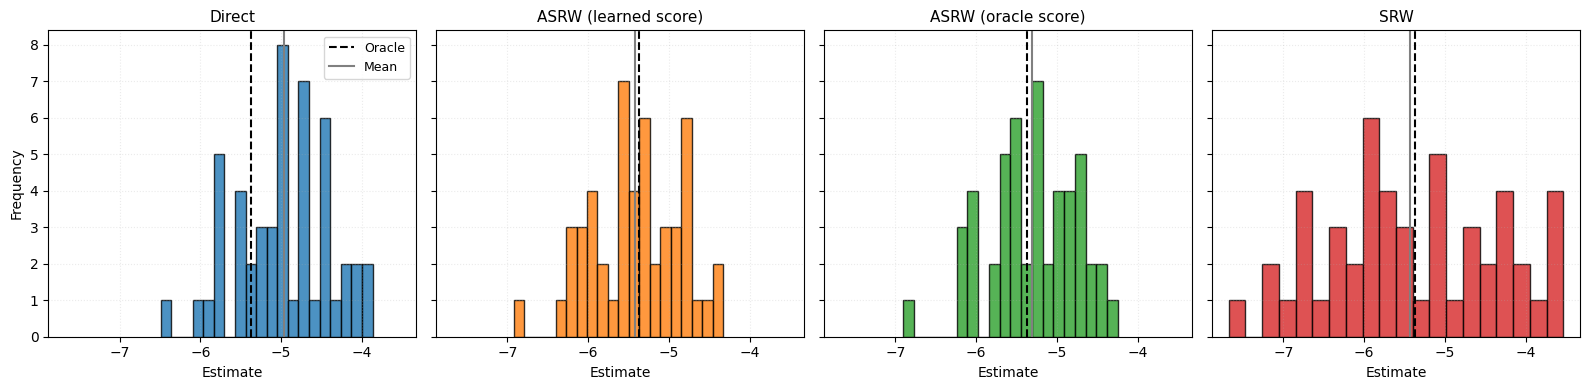

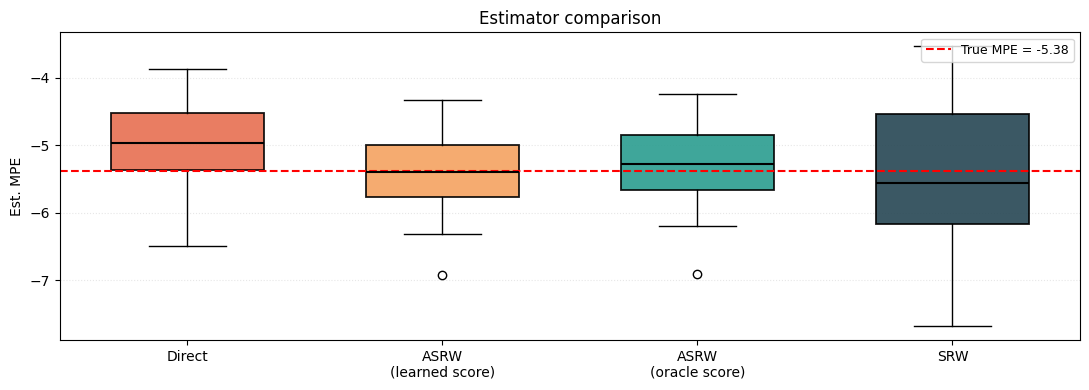

In [9]:
    _ = run_simulation(
        R=50,
        N=5000,
        T = 12,
        n_jobs=-1,
        make_plots=True,
        verbose=True,
    )